In [2]:
from collections import OrderedDict
import torchvision
import torch
from zipfile import ZipFile
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import importlib
import numpy as np
import matplotlib.pyplot as plt


## Time Shift Transform With Params
This notebook implements parameter decoding for time shift augmentation.
The transform returns (1) A clean and time-shifted view of an audio signal and (2) the time shift parameter (in seconds, ranging from -1 to 1).

The time shift is implemented by rolling the audio signal along the time axis.

In [ ]:
from torchvision.transforms import RandomResizedCrop, ToTensor
import numpy as np
from typing import List
from tqdm import tqdm
import matplotlib.pyplot as plt

import torchaudio
import random
import scipy
import sys
import chcochleagram
from chcochleagram import compression
from chcochleagram import cochleagram
from chcochleagram import *
import logging
import sox 
import robustness.audio_functions.audio_transforms as at
importlib.reload(at)

class TimeShiftAugmentation(object):
    def __init__(self, min_shift=-1.0, max_shift=1.0, sample_rate=20_000):
        """
        Time shift augmentation that shifts audio in time.
        
        Args:
            min_shift: Minimum time shift in seconds (default: -1.0)
            max_shift: Maximum time shift in seconds (default: 1.0)
            sample_rate: Sample rate of the audio (default: 20_000)
        """
        super().__init__()
        self.min_shift = min_shift
        self.max_shift = max_shift
        self.sample_rate = sample_rate
        self.torch_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=False)
        self.crop = at.CenterCrop(crop_length=40_000)  # crop to middle 2 seconds

    def __call__(self, aud, background):
        logging.getLogger('sox').setLevel(logging.ERROR)

        assert aud is not None, "aud is None on input"
        clean_aud = self.crop(aud)
        assert clean_aud is not None, "clean aud is None post crop"
        
        # Convert to torch tensor
        clean_aud = torch.from_numpy(clean_aud).float()
        
        # Normalize audio level
        clean_aud, _ = self.torch_set_dbSPL(clean_aud, None)
        
        # Sample a random time shift in seconds
        time_shift_sec = np.random.uniform(self.min_shift, self.max_shift)
        
        # Convert time shift to samples
        shift_samples = int(time_shift_sec * self.sample_rate)
        
        # Apply time shift by rolling the audio
        aug_aud = torch.roll(clean_aud, shifts=shift_samples, dims=-1)
        
        # Reshape to add channel dimension
        aug_aud = aug_aud.reshape(1, -1)
        clean_aud = clean_aud.reshape(1, -1)
        
        # Return as tensor with time shift in seconds
        time_shift_param = torch.tensor([time_shift_sec])
        
        return (clean_aud, aug_aud), time_shift_param





In [4]:
def get_mean_of_uniform(a, b):
    return (a + b) / 2 

def get_std_of_uniform(a, b):
    return np.sqrt(np.square(b - a) / 12.)

def get_uniform_stats(a, b):
    mean = get_mean_of_uniform(a, b)
    std = get_std_of_uniform(a, b)
    return mean, std

##############################
# Get stats for time shift
##############################

time_shift_range = [-1.0, 1.0]  # Time shift in seconds

time_shift_mean, time_shift_std = get_uniform_stats(*time_shift_range)

params_mean = np.array([time_shift_mean], dtype=np.float32)
params_std = np.array([time_shift_std], dtype=np.float32)

print(f"Time shift range: {time_shift_range[0]} to {time_shift_range[1]} seconds")
print(f"Time shift mean: {time_shift_mean:.3f}, std: {time_shift_std:.3f}")

Time shift range: -1.0 to 1.0 seconds
Time shift mean: 0.000, std: 0.577


In [5]:
from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals

batch_size = 96
jsin_path = '/mnt/ceph/users/jfeather/data/training_datasets_audio/JSIN_all_v3/subsets/'

train_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=True,
                                        transform=None,
                                        batch_size=batch_size,
                                        train_max=5  # 10% of training set 
                                        )
val_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=False,
                                        transform=None,
                                        batch_size=batch_size,
                                        eval_max=1)

In [6]:
time_shift_transform = TimeShiftAugmentation(min_shift=-1.0, max_shift=1.0, sample_rate=20_000)

def time_shift_collate_fn(batch):
    batch = batch[0]  # unbox wrapper added by dataloader 
    clean_signals = []
    augmented_signals = []
    params = []
    labels = batch[-1]  # labels already collated 
    
    # convert labels to torch tensors 
    if isinstance(labels, dict):
        for task_key, task_labels in labels.items():
            labels[task_key] = torch.from_numpy(task_labels)
    else:
        labels = torch.from_numpy(labels) 
    
    # apply time shift augmentation
    for (signal, _) in zip(*batch[:2]):
        if signal.sum() == 0 or signal is None:
            continue 
        else:
            (clean_sig, augment_sig), params_i = time_shift_transform(signal, None)
            clean_signals.append(clean_sig)
            augmented_signals.append(augment_sig)
            params.append(params_i)
    
    clean_signals = torch.cat(clean_signals).unsqueeze(1).float()  # add back channel dim
    augmented_signals = torch.cat(augmented_signals).unsqueeze(1).float()  # add back channel dim
    params = torch.stack(params)  # shape: (batch_size, 1)
    
    return clean_signals, augmented_signals, params, labels

In [7]:
time_shift_train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=time_shift_collate_fn
        )

time_shift_test_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=time_shift_collate_fn
        )


In [8]:
clean, aug, params, _ = next(iter(time_shift_test_loader))


In [9]:
print(f"Clean shape: {clean[0].shape}")
print(f"Augmented shape: {aug[0].shape}")
print(f"Time shift params shape: {params.shape}")
print(f"First 5 time shift values (seconds): {params[:5, 0].numpy()}")

Clean shape: torch.Size([1, 40000])
Augmented shape: torch.Size([1, 40000])
Time shift params shape: torch.Size([95, 1])
First 5 time shift values (seconds): [-0.55711156 -0.65751433 -0.6073073   0.94723153  0.47607425]


In [10]:
from IPython.display import display, Audio

eg_ix = 2
print(f"Example {eg_ix}: Time shift = {params[eg_ix, 0].item():.3f} seconds")
print("Clean audio:")
display(Audio(clean[eg_ix], rate=20_000, normalize=False))
print("Time-shifted audio:")
display(Audio(aug[eg_ix], rate=20_000, normalize=False))

Example 2: Time shift = -0.607 seconds
Clean audio:


Time-shifted audio:


## Feature Extraction

- load a pair of models
- extract features in response to clean/augmented views for each

In [11]:
def get_rep_wrapped_model(model, input, layer):
    if layer == 'invar_head':
        feature, rep, logits = model(input)
        if len(rep) == 2:
            rep, _ = rep
    elif layer == 'equivar_head':
        feature, (_, rep), logits = model(input)
    else:
        predictions, rep, all_outputs = model(input,  with_latent=True, fake_relu=False)
        rep = all_outputs[layer]
    rep = rep.flatten(start_dim=1)
    return rep
  
def extract_features_param_decoding(model_1, model_2, loader, layer='avgpool', num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2,  = [], [], [], []
    params, labels = [], []
    n_ = 0
    with torch.no_grad():
        for clean_audio, augmented_audio, param, label in tqdm(loader):
            clean_audio = clean_audio.cuda()
            augmented_audio = augmented_audio.cuda()
            responses_clean_1.append(get_rep_wrapped_model(model_1, clean_audio, layer).cpu())
            responses_augmented_1.append(get_rep_wrapped_model(model_1, augmented_audio, layer).cpu())
            responses_clean_2.append(get_rep_wrapped_model(model_2, clean_audio, layer).cpu())
            responses_augmented_2.append(get_rep_wrapped_model(model_2, augmented_audio, layer).cpu())

            params.append(param)
            labels.append(label)
            n_ += 1
            if n_ == num_batches:
                break

    responses_clean_1 = torch.cat(responses_clean_1)
    responses_augmented_1 = torch.cat(responses_augmented_1)
    responses_clean_2 = torch.cat(responses_clean_2)
    responses_augmented_2 = torch.cat(responses_augmented_2)

    params = torch.cat(params)
    # labels = torch.cat(labels)

    return responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2, params, None


def extract_features_param_decoding_all_layers(model_1, model_2, loader, num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2,  = {}, {}, {}, {}
    params, labels = [], []
    n_ = 0
    with torch.no_grad():
        for ix, (clean_audio, augmented_audio, param, label) in enumerate(tqdm(loader)):
            clean_audio = clean_audio.cuda()
            augmented_audio = augmented_audio.cuda()

            _, _, clean_outs_1 = model_1(clean_audio,  with_latent=True, fake_relu=False)
            _, _, aug_outs_1 = model_1(augmented_audio,  with_latent=True, fake_relu=False)
            _, _, clean_outs_2 = model_2(clean_audio,  with_latent=True, fake_relu=False)
            _, _, aug_outs_2 = model_2(augmented_audio,  with_latent=True, fake_relu=False)

            if ix == 0 :
                responses_clean_1 = {layer:rep.flatten(start_dim=1).cpu() for layer,rep in clean_outs_1.items()}
                responses_augmented_1 = {layer:rep.flatten(start_dim=1).cpu() for layer,rep in aug_outs_1.items()}
                responses_clean_2 = {layer:rep.flatten(start_dim=1).cpu() for layer,rep in clean_outs_2.items()}
                responses_augmented_2 = {layer:rep.flatten(start_dim=1).cpu() for layer,rep in aug_outs_2.items()}
            else:
                for layer in responses_clean_1.keys():
                    responses_clean_1[layer] = torch.cat([responses_clean_1[layer], clean_outs_1[layer].flatten(start_dim=1).cpu()])
                    responses_augmented_1[layer] = torch.cat([responses_augmented_1[layer], aug_outs_1[layer].flatten(start_dim=1).cpu()])
                    responses_clean_2[layer] = torch.cat([responses_clean_2[layer], clean_outs_2[layer].flatten(start_dim=1).cpu()])
                    responses_augmented_2[layer] = torch.cat([responses_augmented_2[layer], aug_outs_2[layer].flatten(start_dim=1).cpu()])

            params.append(param)
            labels.append(label)
            n_ += 1
            if n_ == num_batches:
                break

    params = torch.cat(params)
    # labels = torch.cat(labels)

    return responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2, params, None

In [12]:
import yaml 
import os
from pathlib import Path
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL


ckpt_dir = Path("model_checkpoints")

config_model_invariant_path = Path('model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml')
config_model_invariant = yaml.load(open(config_model_invariant_path, 'r'), Loader=yaml.FullLoader)
invar_ckpt_dir = ckpt_dir / f"{config_model_invariant_path.stem}/checkpoints"
path_model_invariant = sorted(invar_ckpt_dir.glob("*.ckpt"), key=os.path.getctime)[-1]
invar_model_name = config_model_invariant_path.stem

config_model_equivariant_path = Path('model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml')
config_model_equivariant = yaml.load(open(config_model_equivariant_path, 'r'), Loader=yaml.FullLoader)

equivar_ckpt_dir = ckpt_dir / f"{config_model_equivariant_path.stem}/checkpoints"
path_model_equivariant = sorted(equivar_ckpt_dir.glob("*.ckpt"), key=os.path.getctime)[-1]

equivar_model_name = config_model_equivariant_path.stem

invariant_model = LitAudioSSL.load_from_checkpoint(config=config_model_invariant, checkpoint_path=path_model_invariant).model.cuda().eval()
equivariant_model = LitAudioSSL.load_from_checkpoint(config=config_model_equivariant, checkpoint_path=path_model_equivariant).model.cuda().eval()


In [14]:
# Extract Features for time shift decoding 
layer = 'relu4'

print("Extracting features from test set...")
rc_test_1, ra_test_1, rc_test_2, ra_test_2, params_test, labels_test = extract_features_param_decoding(
    invariant_model, 
    equivariant_model, 
    time_shift_test_loader,
    num_batches=5,
    layer=layer
)

print("Extracting features from train set...")
rc_train_1, ra_train_1, rc_train_2, ra_train_2, params_train, labels_train = extract_features_param_decoding(
    invariant_model, 
    equivariant_model, 
    time_shift_train_loader,
    num_batches=50,
    layer=layer
)

# Concatenate clean and augmented features
X1_train = torch.cat([rc_train_1, ra_train_1], dim=1).detach().cpu().numpy()
X2_train = torch.cat([rc_train_2, ra_train_2], dim=1).detach().cpu().numpy()

X1_test = torch.cat([rc_test_1, ra_test_1], dim=1).detach().cpu().numpy()
X2_test = torch.cat([rc_test_2, ra_test_2], dim=1).detach().cpu().numpy()

X1_test = X1_test.reshape(X1_test.shape[0], -1)
X2_test = X2_test.reshape(X2_test.shape[0], -1)
X1_train = X1_train.reshape(X1_train.shape[0], -1)
X2_train = X2_train.reshape(X2_train.shape[0], -1)

# Extract time shift parameter (in seconds)
Y_train_time_shift = params_train[:, 0].detach().cpu().numpy()
Y_test_time_shift = params_test[:, 0].detach().cpu().numpy()

# Reshape for regression
Y_train_time_shift = Y_train_time_shift.reshape(-1, 1)
Y_test_time_shift = Y_test_time_shift.reshape(-1, 1)

# Normalize parameters using empirical stats 
time_shift_mean_empirical = Y_train_time_shift.mean(0)
time_shift_std_empirical = Y_train_time_shift.std(0)

print(f"\nTime shift statistics (empirical):")
print(f"  Mean: {time_shift_mean_empirical[0]:.3f} seconds")
print(f"  Std: {time_shift_std_empirical[0]:.3f} seconds")
print(f"  Train range: [{Y_train_time_shift.min():.3f}, {Y_train_time_shift.max():.3f}] seconds")
print(f"  Test range: [{Y_test_time_shift.min():.3f}, {Y_test_time_shift.max():.3f}] seconds")

Y_train_time_shift_norm = (Y_train_time_shift - time_shift_mean_empirical) / time_shift_std_empirical
Y_test_time_shift_norm = (Y_test_time_shift - time_shift_mean_empirical) / time_shift_std_empirical

# Train linear regression models
print("\nTraining regression models...")
regression_1_time_shift = LinearRegression().fit(X1_train, Y_train_time_shift_norm)
regression_2_time_shift = LinearRegression().fit(X2_train, Y_train_time_shift_norm)

# Evaluate models
score_1_time_shift = regression_1_time_shift.score(X1_test, Y_test_time_shift_norm)
score_2_time_shift = regression_2_time_shift.score(X2_test, Y_test_time_shift_norm)

print(f"\nR² Scores:")
print(f"  Invariant model: {score_1_time_shift:.3f}")
print(f"  Equivariant model: {score_2_time_shift:.3f}")

# Get predictions
preds_1_time_shift = regression_1_time_shift.predict(X1_test).reshape(-1, 1)
preds_2_time_shift = regression_2_time_shift.predict(X2_test).reshape(-1, 1)

Extracting features from test set...


  0%|          | 0/175 [00:00<?, ?it/s]

  2%|▏         | 4/175 [00:02<02:03,  1.39it/s]


Extracting features from train set...


  3%|▎         | 49/1510 [00:25<12:31,  1.94it/s]



Time shift statistics (empirical):
  Mean: -0.002 seconds
  Std: 0.583 seconds
  Train range: [-0.999, 1.000] seconds
  Test range: [-1.000, 0.997] seconds

Training regression models...

R² Scores:
  Invariant model: 0.213
  Equivariant model: 0.292


## Visualization and Evaluation

Now let's visualize the predictions vs. actual time shift values.

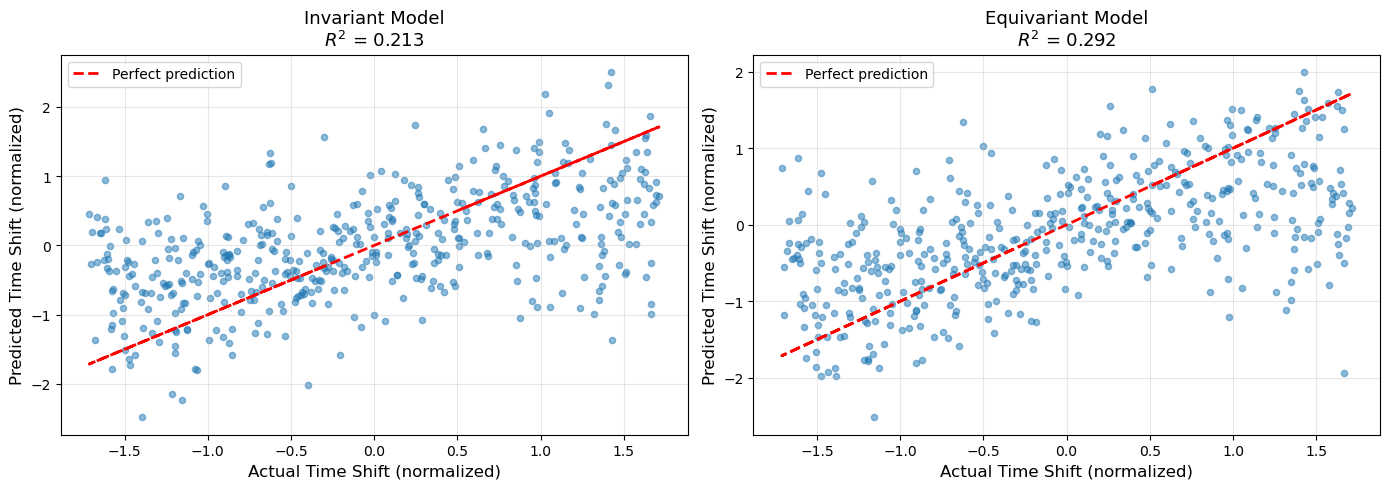

In [15]:
# Scatter plot of predicted vs actual time shift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Invariant model
axes[0].scatter(Y_test_time_shift_norm, preds_1_time_shift, alpha=0.5, s=20)
axes[0].plot(Y_test_time_shift_norm, Y_test_time_shift_norm, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Time Shift (normalized)', fontsize=12)
axes[0].set_ylabel('Predicted Time Shift (normalized)', fontsize=12)
axes[0].set_title(f'Invariant Model\n$R^2$ = {score_1_time_shift:.3f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Equivariant model
axes[1].scatter(Y_test_time_shift_norm, preds_2_time_shift, alpha=0.5, s=20)
axes[1].plot(Y_test_time_shift_norm, Y_test_time_shift_norm, 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Time Shift (normalized)', fontsize=12)
axes[1].set_ylabel('Predicted Time Shift (normalized)', fontsize=12)
axes[1].set_title(f'Equivariant Model\n$R^2$ = {score_2_time_shift:.3f}', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

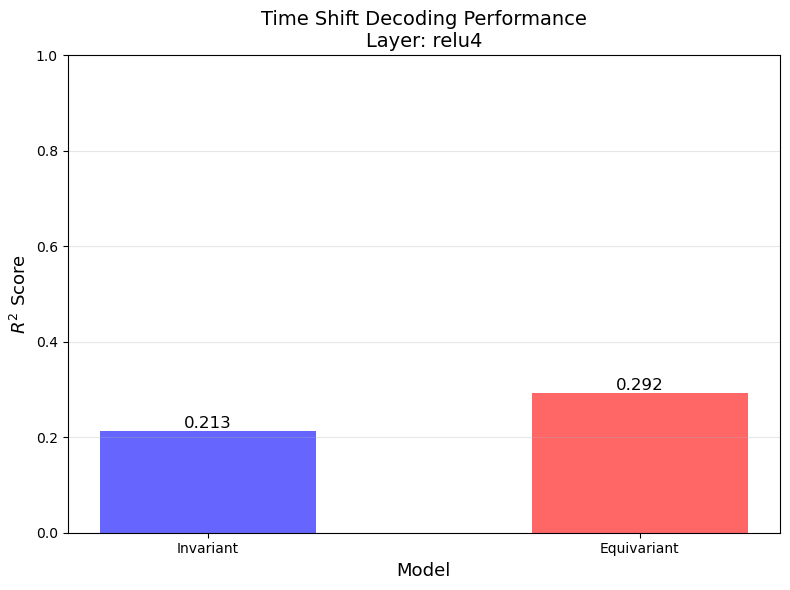

In [16]:
# Bar plot comparing R² scores
fig, ax = plt.subplots(figsize=(8, 6))

models = ['Invariant', 'Equivariant']
scores = [score_1_time_shift, score_2_time_shift]
colors = ['blue', 'red']

bars = ax.bar(models, scores, color=colors, alpha=0.6, width=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('$R^2$ Score', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.set_title(f'Time Shift Decoding Performance\nLayer: {layer}', fontsize=14)
ax.set_ylim(min(0, min(scores) - 0.1), max(1, max(scores) + 0.1))
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}',
            ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


## Pearson's r² Analysis

In [17]:
# Compute R² score for time shift
from scipy.stats import pearsonr

r2_invariant_time_shift = r2_score(Y_test_time_shift_norm[:, 0], preds_1_time_shift[:, 0])
r2_equivariant_time_shift = r2_score(Y_test_time_shift_norm[:, 0], preds_2_time_shift[:, 0])

print(f"R² Scores (sklearn):")
print(f"  Invariant: {r2_invariant_time_shift:.3f}")
print(f"  Equivariant: {r2_equivariant_time_shift:.3f}")


R² Scores (sklearn):
  Invariant: 0.213
  Equivariant: 0.292


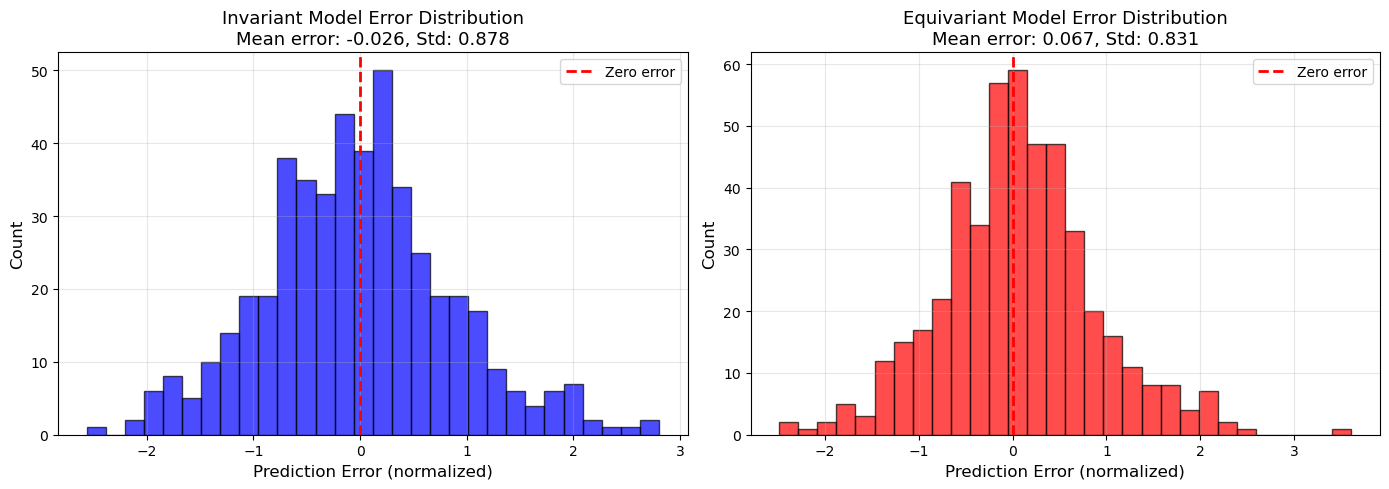

In [18]:
# Distribution of prediction errors
errors_1 = Y_test_time_shift_norm[:, 0] - preds_1_time_shift[:, 0]
errors_2 = Y_test_time_shift_norm[:, 0] - preds_2_time_shift[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Invariant model
axes[0].hist(errors_1, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(0, color='r', linestyle='--', lw=2, label='Zero error')
axes[0].set_xlabel('Prediction Error (normalized)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Invariant Model Error Distribution\nMean error: {errors_1.mean():.3f}, Std: {errors_1.std():.3f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Equivariant model
axes[1].hist(errors_2, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(0, color='r', linestyle='--', lw=2, label='Zero error')
axes[1].set_xlabel('Prediction Error (normalized)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Equivariant Model Error Distribution\nMean error: {errors_2.mean():.3f}, Std: {errors_2.std():.3f}', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
from scipy.stats import pearsonr

# Compute Pearson's r² (signed r²)
def pr2_score(true, pred):
    r, _ = pearsonr(true, pred)
    sign = np.sign(r)
    return sign * np.power(r, 2)

pr2_invariant_time_shift = pr2_score(Y_test_time_shift_norm[:, 0], preds_1_time_shift[:, 0])
pr2_equivariant_time_shift = pr2_score(Y_test_time_shift_norm[:, 0], preds_2_time_shift[:, 0])

print(f"Pearson's r² Scores:")
print(f"  Invariant: {pr2_invariant_time_shift:.3f}")
print(f"  Equivariant: {pr2_equivariant_time_shift:.3f}")

Pearson's r² Scores:
  Invariant: 0.278
  Equivariant: 0.344


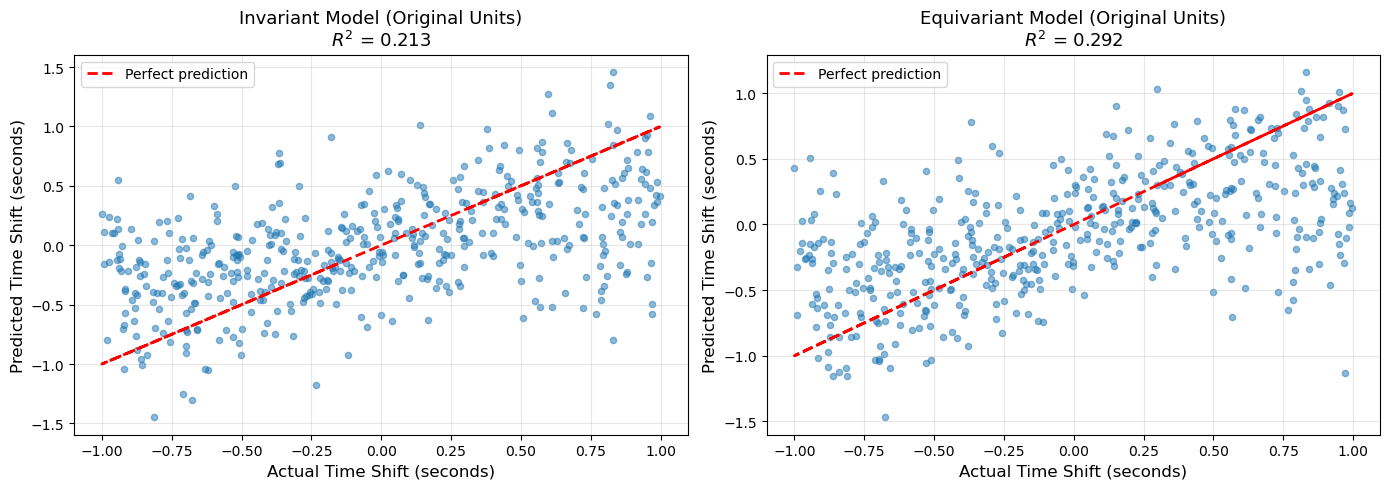

In [20]:
# Compare predictions in original units (seconds)
# Denormalize predictions
preds_1_time_shift_denorm = (preds_1_time_shift * time_shift_std_empirical) + time_shift_mean_empirical
preds_2_time_shift_denorm = (preds_2_time_shift * time_shift_std_empirical) + time_shift_mean_empirical

# Scatter plot in original units
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Invariant model
axes[0].scatter(Y_test_time_shift, preds_1_time_shift_denorm, alpha=0.5, s=20)
axes[0].plot(Y_test_time_shift, Y_test_time_shift, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Time Shift (seconds)', fontsize=12)
axes[0].set_ylabel('Predicted Time Shift (seconds)', fontsize=12)
axes[0].set_title(f'Invariant Model (Original Units)\n$R^2$ = {score_1_time_shift:.3f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Equivariant model
axes[1].scatter(Y_test_time_shift, preds_2_time_shift_denorm, alpha=0.5, s=20)
axes[1].plot(Y_test_time_shift, Y_test_time_shift, 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Time Shift (seconds)', fontsize=12)
axes[1].set_ylabel('Predicted Time Shift (seconds)', fontsize=12)
axes[1].set_title(f'Equivariant Model (Original Units)\n$R^2$ = {score_2_time_shift:.3f}', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
# Summary statistics
print("="*60)
print("TIME SHIFT DECODING SUMMARY")
print("="*60)
print(f"\nModel configurations:")
print(f"  Invariant model: {invar_model_name}")
print(f"  Equivariant model: {equivar_model_name}")
print(f"  Layer: {layer}")
print(f"\nTime shift parameter range: -1.0 to 1.0 seconds")
print(f"Sample rate: 20,000 Hz")
print(f"\nTest set size: {len(Y_test_time_shift)} examples")
print(f"Train set size: {len(Y_train_time_shift)} examples")
print(f"\nDecoding Performance:")
print(f"  Invariant model:")
print(f"    - R² score: {score_1_time_shift:.4f}")
print(f"    - Pearson's r²: {pr2_invariant_time_shift:.4f}")
print(f"    - Mean error: {errors_1.mean():.4f} (normalized)")
print(f"    - RMSE: {np.sqrt((errors_1**2).mean()):.4f} (normalized)")
print(f"\n  Equivariant model:")
print(f"    - R² score: {score_2_time_shift:.4f}")
print(f"    - Pearson's r²: {pr2_equivariant_time_shift:.4f}")
print(f"    - Mean error: {errors_2.mean():.4f} (normalized)")
print(f"    - RMSE: {np.sqrt((errors_2**2).mean()):.4f} (normalized)")
print("="*60)


TIME SHIFT DECODING SUMMARY

Model configurations:
  Invariant model: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only
  Equivariant model: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only
  Layer: relu4

Time shift parameter range: -1.0 to 1.0 seconds
Sample rate: 20,000 Hz

Test set size: 475 examples
Train set size: 4760 examples

Decoding Performance:
  Invariant model:
    - R² score: 0.2133
    - Pearson's r²: 0.2784
    - Mean error: -0.0255 (normalized)
    - RMSE: 0.8786 (normalized)

  Equivariant model:
    - R² score: 0.2917
    - Pearson's r²: 0.3441
    - Mean error: 0.0667 (normalized)
    - RMSE: 0.8336 (normalized)


In [22]:
# Optional: Save results for later analysis
results = {
    'invariant_r2': score_1_time_shift,
    'equivariant_r2': score_2_time_shift,
    'invariant_pr2': pr2_invariant_time_shift,
    'equivariant_pr2': pr2_equivariant_time_shift,
    'invariant_predictions': preds_1_time_shift_denorm,
    'equivariant_predictions': preds_2_time_shift_denorm,
    'actual_time_shifts': Y_test_time_shift,
    'layer': layer,
    'invar_model_name': invar_model_name,
    'equivar_model_name': equivar_model_name
}

print("\nResults dictionary created. Use 'results' variable to access the data.")


Results dictionary created. Use 'results' variable to access the data.
